In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from feynman import Diagram
from feynman import Line

In [2]:
class Theme:
    theme = "light"
    @staticmethod
    def set(_theme):
        Theme.theme = _theme
        if(Theme.theme == "dark"):
            plt.style.use('dark_background')
        else:
            plt.style.use('default')
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['cmr10']  # Основной шрифт для текста
        plt.rcParams['mathtext.fontset'] = 'cm'
    @staticmethod
    def color():
        if(Theme.theme == "light"):
            return "black"
        else:
            return "white"
    @staticmethod
    def back():
        if(Theme.theme == "light"):
            return "white"
        else:
            return "black"
    @staticmethod
    def suff():
        if(Theme.theme == "light"):
            return "l"
        else:
            return "d"

## Unitary triangle

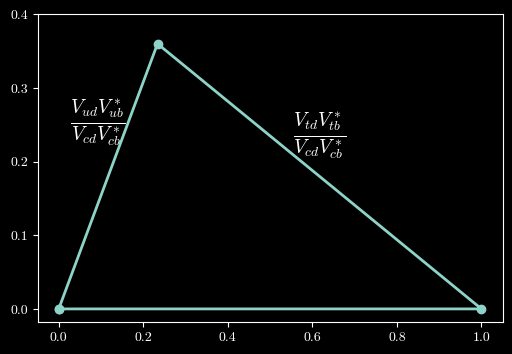

In [ ]:
import numpy as np
Theme.set("dark")

Vud, Vus, Vub = 0.974, 0.227, 0.004 * np.exp(-1j * np.deg2rad(57))
Vcd, Vcs, Vcb = 0.227, 0.973, 0.04
Vtd, Vts, Vtb = 0.008 * np.exp(-1j * np.deg2rad(57)), 0.04, 0.999

A = Vud * np.conj(Vub) / (Vcd * np.conj(Vcb))
B = 1  # единичный вектор (середина)
C = Vtd * np.conj(Vtb) / (Vcd * np.conj(Vcb))

z0 = 0
z1 = B
z2 = A

triangle = np.array([z0, z1, z2, z0])


plt.figure(figsize=(6,4))

plt.plot(triangle.real, triangle.imag, '-o', lw=2)

Ztext = 0.75*z2+0.38*z1
plt.text(Ztext.real, Ztext.imag, '$\\frac{V_{td}V_{tb}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')
Ztext1 = 0.8*z2-0.16
plt.text(Ztext1.real, Ztext1.imag, '$\\frac{V_{ud}V_{ub}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')

plt.yticks([0,0.1,0.2,0.3,0.4])
plt.axis()
plt.savefig('../docs/KaonDecay/CKM/images/unitary-triangle-d.svg',transparent=True)
plt.show()



## Diagramm n->p

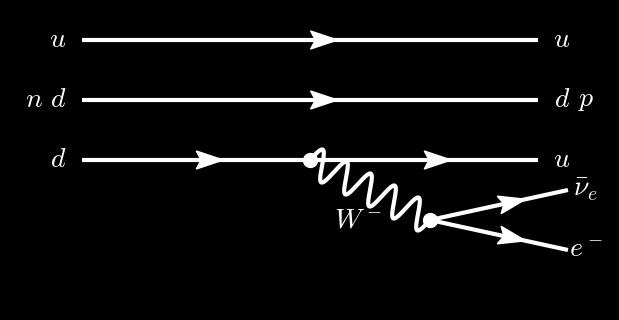

In [256]:


#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(10*0.6,5*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 0.5)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.5
# Вершины
in1 = diagram.vertex(xy=(dX+0.12, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.12, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона
in3 = diagram.vertex(xy=(dX+0.12, image_h-0.25), marker='', **style_params)  # d-кварк нейтрона

out1 = diagram.vertex(xy=(dX+0.88, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.88, image_h-0.15), marker='', **style_params)  # d-кварк протона
out3 = diagram.vertex(xy=(dX+0.88, image_h-0.25), marker='', **style_params)  # u-кварк протона

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.25), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.35), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.93, image_h-0.4), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.93, image_h-0.3), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(in1, out1, **style_params, arrow_param=style_params)
d_line1 = diagram.line(in2, out2, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in3, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out3, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.08, image_h-0.25, r"$d$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.92, image_h-0.25, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.03, out_e.xy[1], r"$e^-$", fontsize=20)
diagram.text(out_nu.xy[0]+0.03, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+0.96, image_h-0.15, r"$p$", fontsize=20)
diagram.text(dX+0.04, image_h-0.15, r"$n$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/n-decay-{Theme.suff()}.svg',transparent=True)

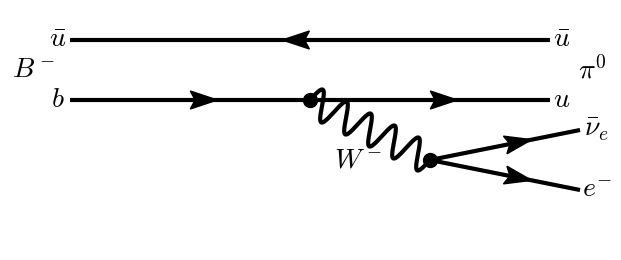

In [250]:

Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(10*0.6,4*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.0
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
# Вершины
in1 = diagram.vertex(xy=(dX+0.1, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.1, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона=

out1 = diagram.vertex(xy=(dX+0.9, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.9, image_h-0.15), marker='', **style_params)  # d-кварк протона=

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.15), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.25), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.95, image_h-0.3), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.95, image_h-0.2), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(out1, in1, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in2, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out2, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$b$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.028, out_e.xy[1], r"$e^{-}$", fontsize=20)
diagram.text(out_nu.xy[0]+0.028, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+0.97, image_h-0.1, r"$\pi^0$", fontsize=20)
diagram.text(dX+0.04, image_h-0.1, r"$B^-$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/B-decay-{Theme.suff()}.svg',transparent=True)

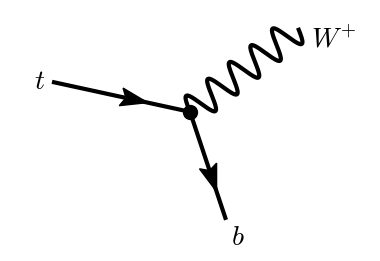

In [ ]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.25
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
cw= 0.3
# Вершины
in1 = diagram.vertex(xy=(cw-0.23, 0.28), marker='', **style_params) 
cener = diagram.vertex(xy=(cw, 0.23), **style_params) 
outW = diagram.vertex(xy=(cw+0.18, 0.37), marker='', **style_params)  
outq = diagram.vertex(xy=(cw+0.06, 0.05), marker='', **style_params)  


tin_line = diagram.line(in1, cener, **style_params, arrow_param=style_params)
qout_line = diagram.line(cener, outq, **style_params, arrow_param=style_params)
w_line = diagram.line(cener, outW, style='wiggly', **style_params)

diagram.text(in1.xy[0]-0.02, in1.xy[1], r"$t$", fontsize=20)
diagram.text(outq.xy[0]+0.02, outq.xy[1]-0.03, r"$b$", fontsize=20)
diagram.text(outW.xy[0]+0.06, outW.xy[1]-0.02, r"$W^{+}$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/tq-decay-{Theme.suff()}.svg',transparent=True)

## Phi 4

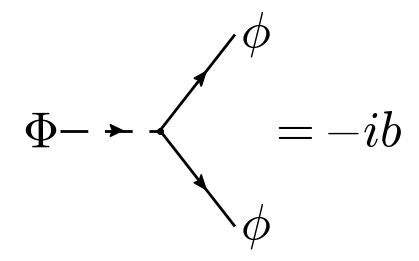

In [317]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.2), marker='', **style_params) 
center = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.45, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.45, H-0.04), marker='', **style_params)

diagram.line(in1, center, **style_params,style='dashed',linewidth=2,arrow_param=arrow_params)
diagram.line(center, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(in1.xy[0]-0.04, in1.xy[1]-0.005, r"$\Phi$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1], r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1], r"$\phi$", fontsize=36)

diagram.text(out2.xy[0]+0.2, center.xy[1]-0.005, r"$=-ib$", fontsize=36)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Phi-2phi-{Theme.suff()}.svg',transparent=True)

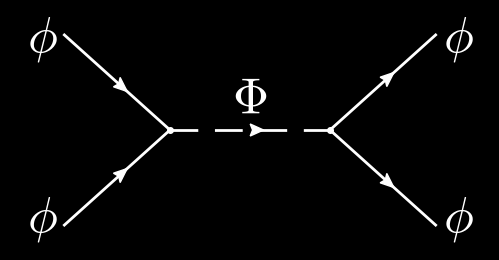

In [341]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='dashed',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.05, r"$\Phi$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4-{Theme.suff()}.svg',transparent=True)

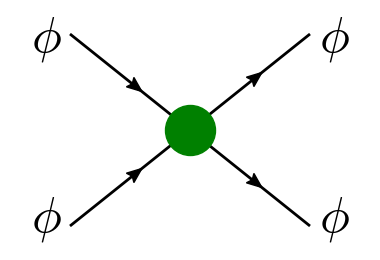

In [361]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), color="green",markersize=36)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(in1,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4_Full-{Theme.suff()}.svg',transparent=True)

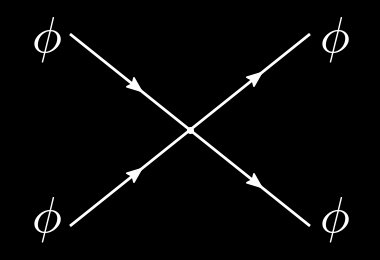

In [363]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(in1,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\phi$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\phi$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/phi4_EFT-{Theme.suff()}.svg',transparent=True)

In [371]:
2.4*1/0.4

5.999999999999999

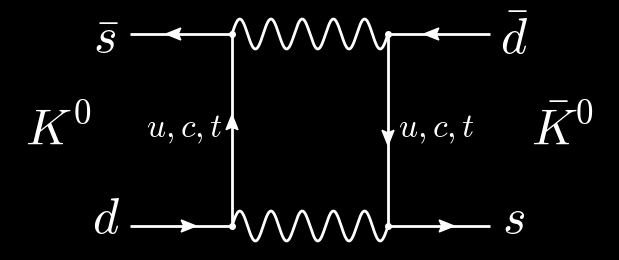

In [393]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.04
in2_y = H-0.04

in1 = diagram.vertex(xy=(0.2, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.2, in2_y), marker='', **style_params)

center1_u = diagram.vertex(xy=(0.37, in1_y), **style_params,markersize=4)
center1_d = diagram.vertex(xy=(0.37, in2_y), **style_params,markersize=4)

center2_u = diagram.vertex(xy=(0.63, in1_y), **style_params,markersize=4)
center2_d = diagram.vertex(xy=(0.63, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.8, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, in2_y), marker='', **style_params)

diagram.line(in1,center1_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, center2_u, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d, center2_d, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u,center1_d, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2_d,center2_u, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(out2,center2_d,  **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.12, H/2, r"$K^{0}$", fontsize=36)
diagram.text(out1.xy[0]+0.12,H/2, r"$\bar{K}^0$", fontsize=36)

diagram.text(center1_u.xy[0]-0.08, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center2_u.xy[0]+0.08, H/2, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$s$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{d}$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Kosc-{Theme.suff()}.svg',transparent=True)

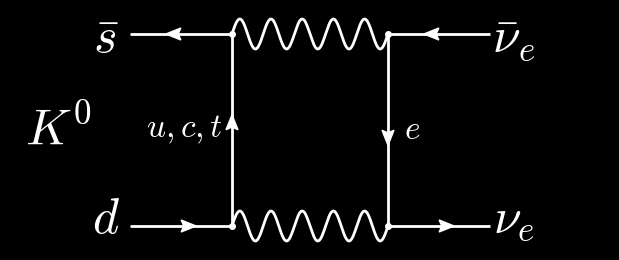

In [404]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.4)

H = 0.4
in1_y = 0.04
in2_y = H-0.04

in1 = diagram.vertex(xy=(0.2, in1_y), marker='', **style_params)
in2 = diagram.vertex(xy=(0.2, in2_y), marker='', **style_params)

center1_u = diagram.vertex(xy=(0.37, in1_y), **style_params,markersize=4)
center1_d = diagram.vertex(xy=(0.37, in2_y), **style_params,markersize=4)

center2_u = diagram.vertex(xy=(0.63, in1_y), **style_params,markersize=4)
center2_d = diagram.vertex(xy=(0.63, in2_y), **style_params,markersize=4)

out1 = diagram.vertex(xy=(0.8, in1_y), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, in2_y), marker='', **style_params)

diagram.line(in1,center1_u, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u, center2_u, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center1_d, center2_d, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)

diagram.line(center1_u,center1_d, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2_d,center2_u, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center2_u, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2_d, **style_params,linewidth=2,arrow_param=arrow_params)



diagram.text(in1.xy[0]-0.12, H/2, r"$K^{0}$", fontsize=36)

diagram.text(center1_u.xy[0]-0.08, H/2, r"$u,c,t$", fontsize=24)
diagram.text(center2_u.xy[0]+0.04, H/2, r"$e$", fontsize=24)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\nu_e$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$\bar{\nu}_e$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\bar{s}$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/KLDecay-{Theme.suff()}.svg',transparent=True)

## Decay $ b \to s + \gamma $

In [ ]:
from feynman import Line

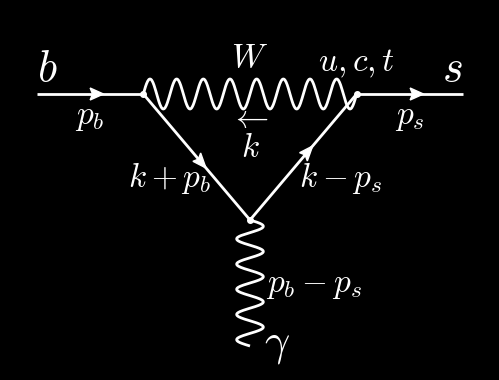

In [473]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,3.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.6)

H = 0.6

Up = H-0.14
Down = 0.04

in1 = diagram.vertex(xy=(0.05, Up), marker='', **style_params)

center1 = diagram.vertex(xy=(0.25, Up), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.65, Up), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.85, Up), marker='', **style_params)

#Line()
diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1, center2, **style_params,style='wiggly',nwiggles=8,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

centerL =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, H/2-0.05), **style_params,markersize=4)

outG =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, 0.04),marker='', **style_params,markersize=4)

diagram.line(center1, centerL, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(centerL, center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(centerL, outG, **style_params,linewidth=2,style='wiggly',arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.06, r"$W$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.04, r"$\leftarrow$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.09, r"$k$", fontsize=24)
diagram.text(center2.xy[0], center2.xy[1]+0.05, r"$u,c,t$", fontsize=24)

diagram.text(out1.xy[0]-0.02, out1.xy[1]+0.04, r"$s$", fontsize=32)
diagram.text(in1.xy[0]+0.02, out1.xy[1]+0.04, r"$b$", fontsize=32)

diagram.text(center1.xy[0]+0.05, H/2+0.02, r"$k + p_b$", fontsize=24)
diagram.text(center2.xy[0]-0.03, H/2+0.02, r"$k - p_s$", fontsize=24)

diagram.text(out1.xy[0]-0.1, out1.xy[1]-0.04, r"$p_s$", fontsize=24)
diagram.text(in1.xy[0]+0.1, out1.xy[1]-0.04, r"$p_b$", fontsize=24)

diagram.text(outG.xy[0]+0.12, outG.xy[1]+0.1, r"$p_b-p_s$", fontsize=24)
diagram.text(outG.xy[0]+0.05, outG.xy[1], r"$\gamma$", fontsize=32)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/BSGamma_1-{Theme.suff()}.svg',transparent=True)

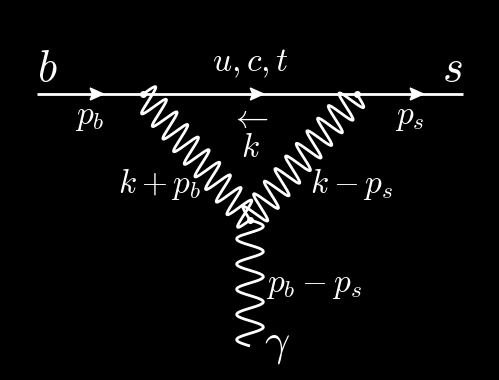

In [486]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,3.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.6)

H = 0.6

Up = H-0.14
Down = 0.04

in1 = diagram.vertex(xy=(0.05, Up), marker='', **style_params)

center1 = diagram.vertex(xy=(0.25, Up), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.65, Up), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.85, Up), marker='', **style_params)

#Line()
diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1, center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

centerL =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, H/2-0.05), **style_params,markersize=4)

outG =  diagram.vertex(xy=((in1.xy[0]+out1.xy[0])/2, 0.04),marker='', **style_params,markersize=4)

diagram.line(center1, centerL, **style_params,linewidth=2,style='wiggly',nwiggles=10,arrow_param=arrow_params)
diagram.line(centerL, center2, **style_params,linewidth=2,style='wiggly',nwiggles=10,arrow_param=arrow_params)

diagram.line(centerL, outG, **style_params,linewidth=2,style='wiggly',arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.05, r"$u,c,t$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.04, r"$\leftarrow$", fontsize=24)
diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]-0.09, r"$k$", fontsize=24)
diagram.text(out1.xy[0]-0.02, out1.xy[1]+0.04, r"$s$", fontsize=32)
diagram.text(in1.xy[0]+0.02, out1.xy[1]+0.04, r"$b$", fontsize=32)

diagram.text(center1.xy[0]+0.03, H/2+0.01, r"$k + p_b$", fontsize=24)
diagram.text(center2.xy[0]-0.01, H/2+0.01, r"$k - p_s$", fontsize=24)

diagram.text(out1.xy[0]-0.1, out1.xy[1]-0.04, r"$p_s$", fontsize=24)
diagram.text(in1.xy[0]+0.1, out1.xy[1]-0.04, r"$p_b$", fontsize=24)

diagram.text(outG.xy[0]+0.12, outG.xy[1]+0.1, r"$p_b-p_s$", fontsize=24)
diagram.text(outG.xy[0]+0.05, outG.xy[1], r"$\gamma$", fontsize=32)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/BSGamma_2-{Theme.suff()}.svg',transparent=True)

## Oprator renormalization in QFT

### Example with QED

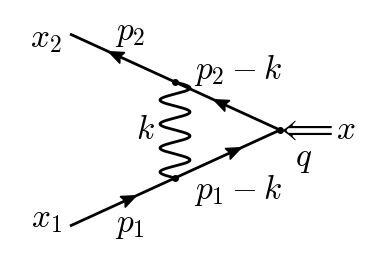

In [60]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center = diagram.vertex(xy=(0.45, 0.2), **style_params,markersize=4)

a_c = 0.5
b_c = 1-a_c
center1 = diagram.vertex(xy=a_c*in1.xy+b_c*center.xy, **style_params,markersize=4)
center2 = diagram.vertex(xy=a_c*in2.xy+b_c*center.xy, **style_params,markersize=4)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,in2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1,center, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1,center2, **style_params,style='wiggly',linewidth=2, nwiggles=4,arrow_param=arrow_params)

diagram.text(in1.xy[0]-0.04, in1.xy[1]+0.01, r"$x_1$", fontsize=24)
diagram.text(in2.xy[0]-0.04, in2.xy[1]-0.01, r"$x_2$", fontsize=24)

diagram.text(center.xy[0]+0.11, center.xy[1], r"$x$", fontsize=24)

diagram.text(center.xy[0]+0.04, center.xy[1], r"$\Longleftarrow$", fontsize=24)
diagram.text(center.xy[0]+0.04, center.xy[1]-0.05, r"$q$", fontsize=24)

diagram.text( 0.2,0.04,r'$p_1$', fontsize=24)
diagram.text( 0.2,H-0.04,r'$p_2$', fontsize=24)
diagram.text(center1.xy[0]-0.05,center.xy[1],r'$k$', fontsize=24)
diagram.text(0.38,0.1,r'$p_1 - k$', fontsize=24)
diagram.text(0.38,H-0.1,r'$p_2 - k$', fontsize=24)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/RenormJ-1-{Theme.suff()}.svg',transparent=True)

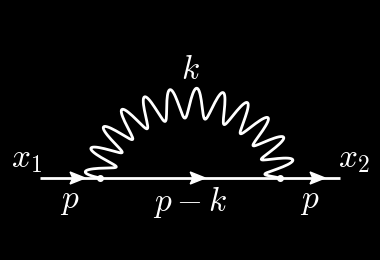

In [94]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.05, 0.12), marker='', **style_params)
out1 = diagram.vertex(xy=(0.55, 0.12), marker='', **style_params)

a_c = 0.8
b_c = 1-a_c
#Line()

center1 = diagram.vertex(xy=a_c*in1.xy+b_c*out1.xy, **style_params,markersize=4)
center2 = diagram.vertex(xy=a_c*out1.xy+b_c*in1.xy, **style_params,markersize=4)

diagram.line(in1,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line(center1,center2, **style_params,style='wiggly',shape="elliptic",circle_angle =2, linewidth=2, nwiggles=12,arrow_param=arrow_params)

diagram.text(in1.xy[0]-0.023, in1.xy[1]+0.03, r"$x_1$", fontsize=24)
diagram.text(out1.xy[0]+0.023, out1.xy[1]+0.03, r"$x_2$", fontsize=24)

diagram.text( in1.xy[0]+0.05,in1.xy[1]-0.04,r'$p$', fontsize=24)
diagram.text( out1.xy[0]-0.05,out1.xy[1]-0.04,r'$p$', fontsize=24)
diagram.text(0.3,0.3,r'$k$', fontsize=24)
diagram.text(0.3,out1.xy[1]-0.04,r'$p - k$', fontsize=24)

diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/RenormJ-2-{Theme.suff()}.svg',transparent=True)

## Effective operators Weak

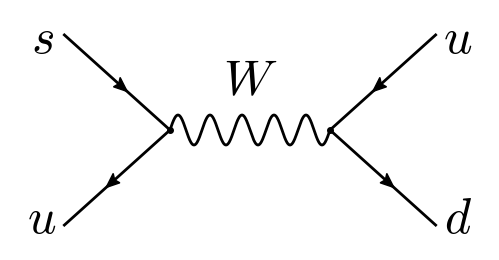

In [115]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.08, r"$W$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$u$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$u$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$s$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/Wsuud-{Theme.suff()}.svg',transparent=True)

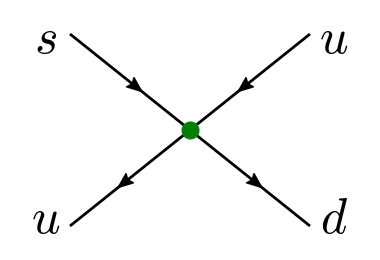

In [117]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center2 = diagram.vertex(xy=(0.3, 0.2), color="green",markersize=12)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)

diagram.line(center2,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$d$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$u$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$u$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$s$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/suudEff1-{Theme.suff()}.svg',transparent=True)

## L4 renorm

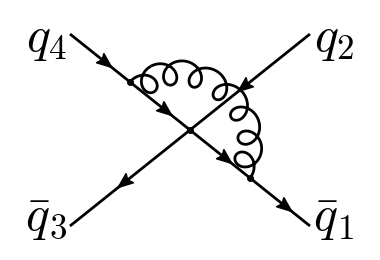

In [184]:
Theme.set("light")
#Theme.set("dark")

gluon_in = 2
gluon_out = 1

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}

fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4


in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)

center2 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.5, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.5, H-0.04), marker='', **style_params)


if(gluon_in == 1):
    p_gluon_in = diagram.vertex(xy=(in1.xy+center2.xy)/2, **style_params,markersize=4)
else:
    p_gluon_in = diagram.vertex(xy=(in2.xy+center2.xy)/2, **style_params,markersize=4)

if(gluon_out == 1):
    p_gluon_out = diagram.vertex(xy=(out1.xy+center2.xy)/2, **style_params,markersize=4)
else:
    p_gluon_out = diagram.vertex(xy=(out2.xy+center2.xy)/2, **style_params,markersize=4)

if(gluon_in == 1):
    diagram.line(p_gluon_in,in1, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(center2,p_gluon_in, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(in2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
else:
    diagram.line(in2,p_gluon_in ,**style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(p_gluon_in,center2, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(center2,in1, **style_params,linewidth=2,arrow_param=arrow_params)

if(gluon_out == 1):
    diagram.line(center2,p_gluon_out, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(p_gluon_out,out1, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)
else:
    diagram.line(p_gluon_out,center2, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line(out2,p_gluon_out, **style_params,linewidth=2,arrow_param=arrow_params)
    diagram.line( center2,out1, **style_params,linewidth=2,arrow_param=arrow_params)

if(gluon_in == gluon_out):
    Gluon = Line(
        p_gluon_in, p_gluon_out, **style_params,
        style='loopy', linewidth=2, nloops=5,
        phase=0.,xamp=0.02,yamp=(gluon_in-1.5)*2*0.02,
        arrow_param=arrow_params)
    diagram.add_line(Gluon)
else:
    Gluon = Line(
        p_gluon_in, p_gluon_out, **style_params,
        style='loopy', linewidth=2, nloops=7,shape="elliptic",
        phase=0.,xamp=0.02,yamp=-0.02,
        arrow_param=arrow_params)
    diagram.add_line(Gluon)

diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\bar{q}_1$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$q_2$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\bar{q}_3$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$q_4$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/L4suud-{gluon_in}{gluon_out}-{Theme.suff()}.svg',transparent=True)

In [136]:
Line

Object `Line.__init__` not found.


## SU(3) Diagramm

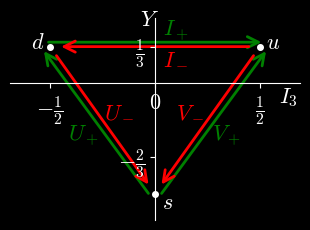

In [60]:
#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()

from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(3.2, 2.4),frameon=True)

quarks = {
    's': (0, -1),
    'u': (0.5, 1/3),
    'd': (-0.5, 1/3),
}

dh1 = 0.08
dh2 = 0.04
quark_offsets= {
    's': (0.06, -dh1),
    'u': ((dh2+dh1)/2, dh2),
    'd': (-(dh2+dh1)/2, dh2),
}

arrow_offsets = {
    's': (0, -dh1),
    'u': ((dh2+dh1)/2, dh2),
    'd': (-(dh2+dh1)/2, dh2),
}


operators = {
    'I_+': {'start': 'd', 'end': 'u', 'offset': (0.1, 0.1), 'color': 'green'},
    'I_-': {'start': 'u', 'end': 'd', 'offset': (0.1, -0.1), 'color': 'red'},
    'U_+': {'start': 's', 'end': 'd', 'offset': (-0.06, -0.12), 'color': 'green'},
    'U_-': {'start': 'd', 'end': 's', 'offset': (0.08, +0.08), 'color': 'red'},
    'V_+': {'start': 's', 'end': 'u', 'offset': (0.06, -0.12), 'color': 'green'},
    'V_-': {'start': 'u', 'end': 's', 'offset': (-0.08, 0.08), 'color': 'red'},
}

# Рисуем кварки
for quark, (x, y) in quarks.items():
    ax.plot(x, y, 'o', markersize=4, color=main_color, linewidth=2)
    (dx,dy) = quark_offsets[quark]
    ax.text(x+dx, y+dy, f'${quark}$', fontsize=16, ha='center', va='center', fontweight='bold')


# Рисуем стрелки операторов
for op_name, op_info in operators.items():

    start_x, start_y = quarks[op_info['start']]
    end_x, end_y = quarks[op_info['end']]
    
    # Сдвигаем начало и конец для избежания наложения

    
    if(op_name.endswith('_-')):
        dx_start = 0
        dy_start = 0
        dx_end = 0
        dy_end = 0
    else:
        (dx_start, dy_start) = arrow_offsets[op_info['start']]
        (dx_end, dy_end) = arrow_offsets[op_info['end']]
    
    start_y = start_y + dy_start
    start_x = start_x + dx_start
    end_y = end_y + dy_end
    end_x = end_x + dx_end
    
    # Рисуем стрелку
    arrow = FancyArrowPatch(posA=(start_x, start_y), 
                        posB=(end_x, end_y),
                        arrowstyle='->', 
                        mutation_scale=20,
                        color=op_info['color'],
                        linewidth=2,
                        shrinkA=8,
                        shrinkB=8,
                        zorder=1)  # Низкий zorder для стрелок

    ax.add_patch(arrow)
    
    # Подписываем оператор (сдвигаем подпись наружу/внутрь)
    
    (tx_tmp, ty_tmp) = op_info['offset']
    text_x = (start_x + end_x) / 2 + tx_tmp 
    text_y = (start_y + end_y) / 2 + ty_tmp

    ax.text(text_x, text_y, f'${op_name}$', fontsize=16, 
            color=op_info['color'], fontweight='bold',
            ha='center', va='center')
    

# подаиси x оси (-$\frac{1}{2}$ 0 1/2)
#сделать через ax.set_xticks и ax.set_xticklabels
ax.set_axisbelow(False)
ax.set_xticks([-0.5, 0, 0.5])
ax.set_xticklabels([r'$-\frac{1}{2}$', r'$0$', r'$\frac{1}{2}$'])
# подписи y оси (-2/3 1/3)
ax.set_yticks([-2/3, 1/3])
ax.set_yticklabels([r'$-\frac{2}{3}$', r'$\frac{1}{3}$'])
ax.tick_params(axis='both', labelsize=16)

# ensure ticks and labels are drawn above other artists

for t in ax.xaxis.get_ticklines() + ax.yaxis.get_ticklines():
    t.set_zorder(10)
for lbl in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels():
    lbl.set_zorder(10)
# хочу подписи на краях осей
# place axes at center, add arrowheads and labels
x_label = r'$I_3$'
y_label = r'$Y$'

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
padx = 0.08 * (xmax - xmin)
pady = 0.08 * (ymax - ymin)
ax.set_xlim(xmin - padx, xmax + padx)
ax.set_ylim(ymin - pady, ymax + pady)

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(main_color)
ax.spines['bottom'].set_color(main_color)



# labels near the arrow tips
ax.text(ax.get_xlim()[1] - 0.01*(xmax-xmin), -0.01*(ymax-ymin), x_label,
        fontsize=16, ha='right', va='top')
ax.text(-0.06*(xmax-xmin), ax.get_ylim()[1] + 0.05*(ymax-ymin), y_label,
        fontsize=16, ha='left', va='top')



plt.tight_layout()
plt.show()
fig.savefig(f'../docs/KaonDecay/FCNC/images/YI3-{Theme.suff()}.svg',transparent=True)

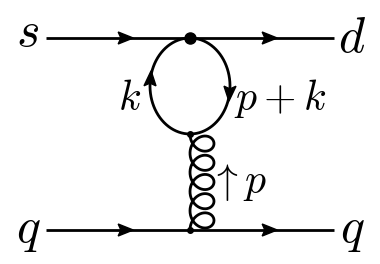

In [138]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4

in1 = diagram.vertex(xy=(0.06, H-0.04), marker='', **style_params)
out1 = diagram.vertex(xy=(0.54, H-0.04), marker='', **style_params)

in2 = diagram.vertex(xy=(0.06, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.54, 0.04), marker='', **style_params)

center12 = diagram.vertex(xy=(0.3, H-0.04),markersize=8, **style_params)

centerU = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
centerD = diagram.vertex(xy=(0.3, 0.04), **style_params,markersize=4)

diagram.line(center12,centerU, **style_params,linewidth=2,shape="elliptic",arrow_param=arrow_params)
diagram.line(centerU,center12, **style_params,linewidth=2,shape="elliptic",arrow_param=arrow_params)

diagram.line(in1,center12, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,centerD, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center12, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( centerD,centerU, **style_params,linewidth=2,style='loopy',phase=0.0,xamp=0.02,yamp=-0.02,nloops=5.0,arrow_param=arrow_params)

diagram.line( centerD,out2, **style_params,linewidth=2,arrow_param=arrow_params)


diagram.text(centerU.xy[0]-0.1, centerU.xy[1]+0.06, r"$k$", fontsize=30)
diagram.text(centerU.xy[0]+0.15, centerU.xy[1]+0.06, r"$p+k$", fontsize=30)

diagram.text(centerU.xy[0]+0.08, centerU.xy[1]-0.08, r"$\uparrow p$", fontsize=30)

diagram.text(out1.xy[0]+0.03, out1.xy[1]+0.0, r"$d$", fontsize=36)
diagram.text(out2.xy[0]+0.03, out2.xy[1]-0.00, r"$q$", fontsize=36)
diagram.text(in1.xy[0]-0.03, out1.xy[1]+0.01, r"$s$", fontsize=36)
diagram.text(in2.xy[0]-0.03, out2.xy[1]-0.00, r"$q$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/KaonDecay/FCNC/images/PinguinFermi-{Theme.suff()}.svg',transparent=True)

## Kaon Decay

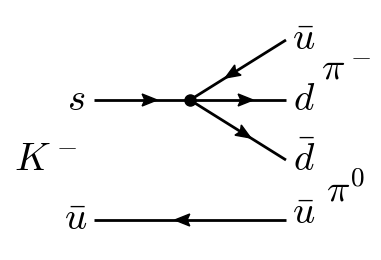

In [ ]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(3.6,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.14, 0.25), marker='', **style_params)
in2 = diagram.vertex(xy=(0.14, 0.05), marker='', **style_params)

center = diagram.vertex(xy=(0.3, 0.25), **style_params,markersize=8)

out1 = diagram.vertex(xy=(0.46, 0.05), marker='', **style_params)
out2 = diagram.vertex(xy=(0.46, 0.15), marker='', **style_params)
out3 = diagram.vertex(xy=(0.46, 0.25), marker='', **style_params)
out4 = diagram.vertex(xy=(0.46, 0.35), marker='', **style_params)

diagram.line(in1,center, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center,out2, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center, out3, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out4,center, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.line( out1,in2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text(out1.xy[0]+0.03, out1.xy[1]+0.01, r"$\bar{u}$", fontsize=28)


diagram.text(out2.xy[0]+0.03, out2.xy[1], r"$d$", fontsize=28)
diagram.text(out3.xy[0]+0.03, out3.xy[1], r"$d$", fontsize=28)
diagram.text(out4.xy[0]+0.03, out4.xy[1], r"$\bar{u}$", fontsize=28)

diagram.text(in1.xy[0]-0.03, in1.xy[1], r"$s$", fontsize=28)
diagram.text(in2.xy[0]-0.03, in2.xy[1], r"$\bar{u}$", fontsize=28)

diagram.text( (in1.xy[0]+in2.xy[0])/2-0.08, (in1.xy[1]+in2.xy[1])/2, r"$K^-$", fontsize=28)
diagram.text( (out1.xy[0]+out2.xy[0])/2+0.1, (out1.xy[1]+out2.xy[1])/2, r"$\pi^0$", fontsize=28)
diagram.text( (out3.xy[0]+out4.xy[0])/2+0.1, (out3.xy[1]+out4.xy[1])/2, r"$\pi^-$", fontsize=28)

diagram.plot()
#fig.savefig(f'../docs/KaonDecay/FCNC/images/KaonDecay3-{Theme.suff()}.svg',transparent=True)